In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/20250904_cleaned_patient_outcomes_data.csv").dropna(subset='Lineage')

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

df_fixed_variants = pd.read_csv("../results/genome/fixed_variants.csv.gz", compression='gzip')
df_unfixed_variants = pd.read_csv("../results/genome/unfixed_variants.csv.gz", compression='gzip')

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

df_LR_assembly_metadata = pd.read_csv("../data/TRUST.PBAsm.ZA_106CI_AssemblySummary.csv")
df_LR_assembly_metadata['Lineage'] = df_LR_assembly_metadata['Lineage_Asm'].str.replace('lineage', '')

# this keeps only those with NumContigs = 1 and numContigs_Complete = 1 in df_LR_assembly_metadata, and the lineages (Coll2014 exactly) of the LR and SR sequences must match
df_personal_assemblies = pd.read_csv("data/personal_assemblies_samples.tsv", sep='\t', header=None)

df_PacBio_seqs = pd.read_csv("~/MtbLongitudinalDiversity/data/230902.trust.lrandsr.set1to4.106ci.inputwgs.paths.tsv", sep='\t').rename(columns={'SampleID': 'Original_ID'})
df_PacBio_seqs = df_PacBio_seqs.merge(df_trust_patients[['SampleID', 'Original_ID']], on='Original_ID')

In [2]:
df_trust_patients.query("SampleID in ['MFS-313', 'MFS-317', 'MFS-377']")[['pid', 'SampleID', 'Original_ID', 'F2', 'Lineage', 'Coll2014', 'Freschi2020']]


,pid,SampleID,Original_ID,F2,Lineage,Coll2014,Freschi2020
544,T0198,MFS-377,S0198-02,0.108434,2.0,2.2.1.1,2.2.1.1.1
729,T0311,MFS-317,S0311-01,0.369685,"2,4","4.3.2.1,2.2.1.1","2.2.1.1.1,4.2.1.2.1.1.i1"
737,T0305,MFS-313,S0305-01,0.436810,"2,4","4.3.2.1,2.2.1.1","2.2.1.1.1,4.2.1.2.1.1.i1"


In [3]:
df_PacBio_seqs.query("Original_ID=='S0305-01'").PacBio_FQ_PATH.values

array(['/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124/m64142_221216_110244.bc2013--bc2013.hifi_reads.fastq.gz'],
      dtype=object)

In [4]:
df_LR_assembly_metadata.query("SampleID=='S0311-01'")

,SampleID,NumContigs,numContigs_Complete,circContig_Length,circContig_Cov,Flye_EstimatedCov,Flye_ReadLen_N50,Flye_ReadLen_N90,Lineage_Asm,Lineage_AsmPP,...,NumTotalInsertions_PilonPolished,Num1bpInsertion_PilonPolished,Num2bpInsertion_PilonPolished,NumTotalDeletions_PilonPolished,Num1bpDeletion_PilonPolished,PrimaryLineage_Asm,Dataset_Tag,PatientID,IsolateNum,Lineage
37,S0311-01,4,1,4409171,149,150,12128,6589,lineage2.2.1.1,lineage2.2.1.1,...,0,0,0,6,3,lineage2,TRUST_PB_Set4,S0311,1,2.2.1.1


In [5]:
# df_compare = df_trust_patients[['pid', 'Original_ID', 'SampleID', 'Coll2014', 'Freschi2020']].dropna().merge(df_LR_assembly_metadata.rename(columns={'SampleID': 'Original_ID'}), on='Original_ID').query("NumContigs==1")

# df_compare.query("Coll2014 != Lineage")[['pid', 'Original_ID', 'SampleID', 'Coll2014', 'Lineage']]

In [6]:
samples_lst = os.listdir(personal_ref_dir)

lowAF_files = glob.glob(f"{personal_ref_dir}/*/freebayes/lowAF_variants.H37Rv.bed")
len(lowAF_files)

108

### Restrict to samples for which all ground truth low-AF variants could be transferred to H37Rv coordinates

In [7]:
same_length_BED_files = []

for fName in lowAF_files:
    
    sample = os.path.basename(os.path.dirname(os.path.dirname(fName)))
    
    try:
        df_H37Rv_BED = pd.read_csv(fName, sep='\t', header=None)
        df_BED = pd.read_csv(fName.replace('.H37Rv', ''), sep='\t')
        
        if len(df_BED) == len(df_H37Rv_BED):
            same_length_BED_files.append(sample)
        else:
            print(sample, len(df_BED), len(df_H37Rv_BED))
    except:
        # print(f"{fName} is empty")
        with open(fName, "r") as file:
            df_H37Rv_BED = file.readlines()
        
        with open(fName.replace('.H37Rv', ''), "r") as file:
            df_BED = file.readlines()
            
        # fName has a header so check that the numbers of lines are off by 1
        if len(df_H37Rv_BED) + 1 == len(df_BED):
             same_length_BED_files.append(sample)
           
print(f"{len(same_length_BED_files)} samples have BED files with the same lengths")

MFS-160 8 7
MFS-26 2 1
MFS-313 1397 1383
MFS-317 1399 1383
MFS-321 3 2
MFS-322 2 1
MFS-323 2 1
MFS-377 1336 1327
MFS-4 9 8
99 samples have BED files with the same lengths


In [8]:
confusion_matrix_files = glob.glob(f"{personal_ref_dir}/*/lowAF_comparison/confusion_matrix.csv")
len(confusion_matrix_files)

108

In [9]:
df_metrics = pd.DataFrame(columns = ['SampleID', 'TP', 'FP', 'FN', 'Sens', 'Precision']).set_index('SampleID')

# will be pivoted to a matrix of SampleID x H37Rv pos, where the values will be TP, FP, or FN. NA = TN (neither low AF variant ground truth or detected by the H37Rv )
df_lowAF_variants_all = []

for fName in confusion_matrix_files:
    
    sample_id = os.path.basename(os.path.dirname(os.path.dirname(fName)))
    
    df = pd.read_csv(fName).drop_duplicates(subset=['POS', 'REF'])
    df['SampleID'] = sample_id
    
    # discrepancies between haplotype variants. In one freebayes annotates an MNP, in another freebayes annotates 2 SNPs
    # but they are at the same site, and I think they should be considered 1 true positive
    if sample_id == 'MFS-135':
        df = df.query("POS != 3606002")
    
    df_lowAF_variants_all.append(df)
    
    # could be nothing detected or ground truth low AF variants
    if len(df) == 0:
        TP = 0
        FN = 0
        FP = 0
    else:
        TP = len(df.query("Result=='TP'"))
        FN = len(df.query("Result=='FN'"))
        FP = len(df.query("Result=='FP'"))

    if TP + FP == 0:
        prec = np.nan
    else:
        prec = TP / (TP + FP)
        
    if TP + FN == 0:
        sens = np.nan
    else:
        sens = TP / (TP + FN)

    df_metrics.loc[sample_id, :] = [TP, FP, FN, sens, prec]
    
df_metrics = df_metrics.reset_index().merge(df_trust_patients[['pid', 'SampleID', 'Sampling_Week', 'F2', 'Coll2014', 'Freschi2020']], on='SampleID', how='left')
df_lowAF_variants_all = pd.concat(df_lowAF_variants_all).reset_index(drop=True)

print(f"{df_lowAF_variants_all.SampleID.nunique()} samples")

108 samples


In [10]:
df_lowAF_variants_all.Result.value_counts()

Result
TP    3805
FP     108
FN      33
Name: count, dtype: int64

### Exclude indels for now because need to write the detector for reads being in the middle of an indel

If you exclude indels, there are no false positives at the moment, cool.

In [11]:
# have to do all this because of NAs. If you do a simple REF.str.len() == ALT.str.len(), it keeps only variants found by both methods
df_lowAF_variants_all['Indel'] = (df_lowAF_variants_all['REF'].str.len() != df_lowAF_variants_all['ALT'].str.len()).astype(int)
df_lowAF_variants_all['H37Rv_Indel'] = (df_lowAF_variants_all['H37Rv_REF'].str.len() != df_lowAF_variants_all['H37Rv_ALT'].str.len()).astype(int)

df_lowAF_variants_all.loc[pd.isnull(df_lowAF_variants_all['REF']), 'Indel'] = 0
df_lowAF_variants_all.loc[pd.isnull(df_lowAF_variants_all['H37Rv_REF']), 'H37Rv_Indel'] = 0

assert sum(pd.isnull(df_lowAF_variants_all['Indel'])) == 0
assert sum(pd.isnull(df_lowAF_variants_all['H37Rv_Indel'])) == 0

df_lowAF_variants_all = df_lowAF_variants_all.query("Indel == 0 & H37Rv_Indel == 0")

print(df_lowAF_variants_all.Result.value_counts())

# can't have NAs to pivot
for col in ['POS', 'REF', 'ALT']:
    df_lowAF_variants_all[col] = df_lowAF_variants_all[col].fillna(df_lowAF_variants_all[f'H37Rv_{col}'])
    
df_lowAF_variants_all['POS'] = df_lowAF_variants_all['POS'].astype(int)

df_lowAF_variants_all['variant'] = df_lowAF_variants_all['POS'].astype(str) + '_' + df_lowAF_variants_all['REF'] + '_' + df_lowAF_variants_all['ALT']

df_lowAF_variants_all['Mixed_Lineage'] = df_lowAF_variants_all['SampleID'].isin(mixed_samples).astype(int)

# TN = 0
lowAF_variants_matrix = df_lowAF_variants_all.query("Mixed_Lineage == 0").pivot(index='SampleID', columns='POS', values='Result').fillna('TN')
lowAF_variants_matrix = lowAF_variants_matrix.replace('TN', 0)
lowAF_variants_matrix = lowAF_variants_matrix.replace('TP', 1)
lowAF_variants_matrix = lowAF_variants_matrix.replace('FP', -1)
lowAF_variants_matrix = lowAF_variants_matrix.replace('FN', -0.5)

# combine to get pid information
lowAF_variants_matrix = lowAF_variants_matrix.merge(df_trust_patients[['pid', 'SampleID', 'Sampling_Week']], left_index=True, right_on='SampleID').sort_values(['pid', 'Sampling_Week']).set_index(['pid', 'SampleID', 'Sampling_Week'])

Result
TP    3527
FP      20
FN      12
Name: count, dtype: int64


In [95]:
# AF_max = 0.75
np.unique(lowAF_variants_matrix.values, return_counts=True)

(array([-1. , -0.5,  0. ,  1. ]), array([   17,     2, 20794,   267]))

In [96]:
if len(np.unique(lowAF_variants_matrix.values)) == 4:

    color_palette = {-1: 'firebrick', # false positive
                     -0.5: 'gold', # false negative
                     0: 'whitesmoke', # true neegative
                     1: 'royalblue' # true positive
                    }
    
elif len(np.unique(lowAF_variants_matrix.values)) == 3:

    color_palette = {-0.5: 'firebrick', # false positive
                     0: 'whitesmoke', # true neegative
                     1: 'royalblue' # true positive
                    }
else:
    color_palette = {0: 'whitesmoke', # true neegative
                     1: 'royalblue' # true positive
                    }
    
# Map strings to integer codes based on category order
categories = list(color_palette.keys())
codes = np.vectorize(lambda x: categories.index(x))(lowAF_variants_matrix)

# Create custom colormap
custom_cmap = ListedColormap([color_palette[cat] for cat in categories])

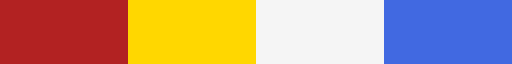

In [97]:
custom_cmap

In [98]:
df_lowAF_variants_all['Count'] = 1
df_lowAF_variants_POS_grouped = df_lowAF_variants_all.query("Mixed_Lineage == 0 & REF.str.len() == ALT.str.len()").groupby(['POS'])[['SampleID']].count().reset_index()

df_lowAF_variants_POS_grouped = df_lowAF_variants_all.query("Mixed_Lineage == 0 & REF.str.len() == ALT.str.len()")[['POS']]
df_lowAF_variants_POS_grouped['SampleID'] = 1

<Axes: xlabel='POS', ylabel='Proportion'>

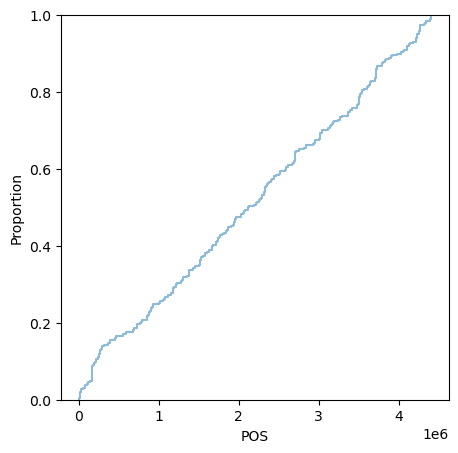

In [99]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.ecdfplot(data=df_lowAF_variants_POS_grouped,
                x='POS',
                ax=ax,
                alpha=0.5
               )

In [101]:
df_lowAF_variants_all.query("Result=='FN' & Mixed_Lineage == 0")

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,SampleID,Indel,H37Rv_Indel,variant,Mixed_Lineage,Count
52,1860116,G,A,NaN,NaN,NaN,FN,MFS-129,0,0,1860116_G_A,0,1
53,2588836,T,C,NaN,NaN,NaN,FN,MFS-129,0,0,2588836_T_C,0,1


In [104]:
df_lowAF_variants_all.query("Result=='FP' & Mixed_Lineage == 0").sort_values('POS')

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,SampleID,Indel,H37Rv_Indel,variant,Mixed_Lineage,Count
220,13627,T,C,13627.0,T,C,FP,MFS-3,0,0,13627_T_C,0,1
101,163705,TT,CC,163705.0,TT,CC,FP,MFS-16,0,0,163705_TT_CC,0,1
136,163705,TT,CC,163705.0,TT,CC,FP,MFS-163,0,0,163705_TT_CC,0,1
168,163705,TT,CC,163705.0,TT,CC,FP,MFS-184,0,0,163705_TT_CC,0,1
3870,163705,TT,CC,163705.0,TT,CC,FP,MFS-55,0,0,163705_TT_CC,0,1
3854,163705,TT,CC,163705.0,TT,CC,FP,MFS-41,0,0,163705_TT_CC,0,1
3842,163705,TT,CC,163705.0,TT,CC,FP,MFS-38,0,0,163705_TT_CC,0,1
3932,163705,TT,CC,163705.0,TT,CC,FP,MFS-70,0,0,163705_TT_CC,0,1
2635,163705,TT,CC,163705.0,TT,CC,FP,MFS-322,0,0,163705_TT_CC,0,1
2673,163705,TT,CC,163705.0,TT,CC,FP,MFS-37,0,0,163705_TT_CC,0,1


<Axes: ylabel='pid-SampleID-Sampling_Week'>

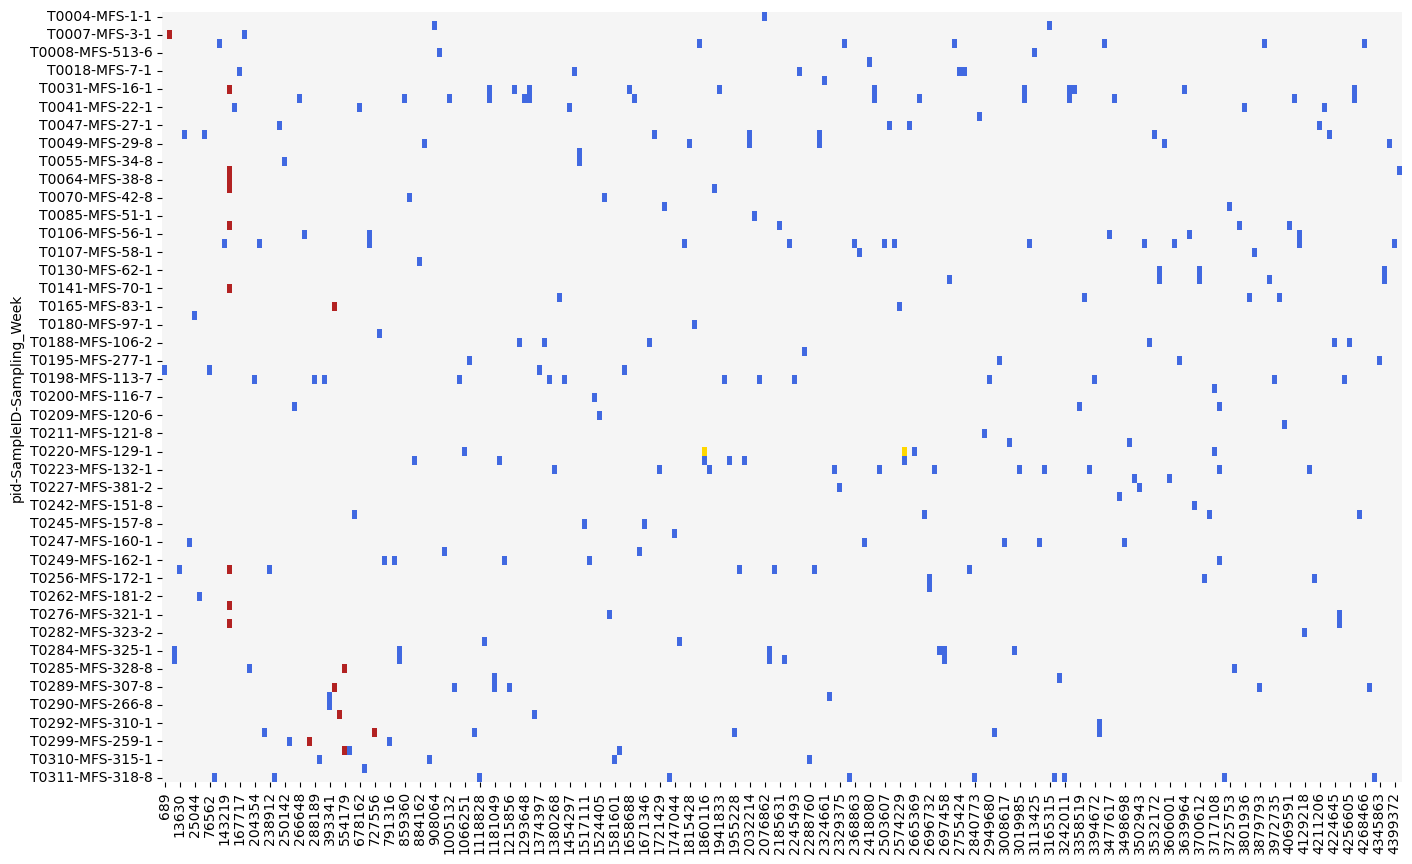

In [105]:
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(lowAF_variants_matrix,
            cmap=custom_cmap,
            cbar=False,
            ax=ax
           )

In [359]:
# for sample in lowAF_variants_matrix.index.values:

#     if -0.5 in lowAF_variants_matrix.loc[sample].value_counts().index.values:
#         num_FN = lowAF_variants_matrix.loc[sample].value_counts().loc[-0.5]

#         if num_FN > 0:
#             print(sample, num_FN)

In [49]:
sample = 'MFS-129'

df_ground_truth = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")
confusion_matrix = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/confusion_matrix.csv").drop_duplicates()
H37Rv_detected = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/H37Rv_detected.csv")

lowAF_variants_bothCoords = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None)
# df_ground_truth['GeneName'] = df_ground_truth['POS'].map(h37Rv_coords_dict)

In [65]:
confusion_matrix.query(f"H37Rv_REF.str.len() == H37Rv_ALT.str.len()").Result.value_counts()

Result
FP    5
TP    3
Name: count, dtype: int64

In [61]:
df_ground_truth.query("REF.str.len() == ALT.str.len()").sort_values('POS')

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
2,1066251,C,T,3.650930e+03,NaN,323,102,221,0.684211,60.000,...,35,67,97,124,24.81020,10.17320,4.19921,4.37279,116.0,105.0
3,1860116,G,A,7.348760e+03,NaN,265,11,254,0.958491,60.000,...,7,4,139,115,4.78696,7.93458,57.72460,7.94546,87.0,167.0
4,2588836,T,C,8.217180e+03,NaN,304,17,287,0.944079,60.000,...,5,12,112,175,9.26925,33.04020,12.27880,3.13803,126.0,161.0
5,2665369,G,A,1.158400e-13,NaN,266,228,38,0.142857,60.000,...,117,111,16,22,3.35316,5.06748,5.06748,3.96270,16.0,22.0
6,3717108,C,A,3.679100e+03,NaN,299,89,210,0.702341,59.981,...,36,53,84,126,10.06150,21.25070,5.65743,18.25940,97.0,113.0


In [62]:
H37Rv_detected.query("REF.str.len() == ALT.str.len()").sort_values('POS')

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
4,163705,TT,CC,8.114680e+03,NaN,285,0,272,0.954386,59.8934,...,0,0,95,177,0.00000,56.69040,3.04223,0.00000,137.0,135.0
8,850507,T,A,0.000000e+00,NaN,191,169,22,0.115183,60.0000,...,91,78,15,7,5.18177,9.32731,50.78270,369.98900,0.0,22.0
10,1066251,T,C,3.650930e+03,NaN,323,102,221,0.684211,60.0000,...,35,67,97,124,24.81020,10.17320,4.19921,4.37279,116.0,105.0
24,2591484,A,G,7.978720e+01,NaN,534,265,269,0.503745,59.9554,...,133,132,86,183,3.01849,78.96340,14.06140,37.63090,116.0,153.0
25,2592310,A,G,2.925430e+03,NaN,492,203,289,0.587398,60.0000,...,81,122,167,122,20.99180,18.22560,36.73950,287.21600,111.0,178.0
26,2665369,G,A,1.158400e-13,NaN,266,228,38,0.142857,60.0000,...,117,111,16,22,3.35316,5.06748,5.06748,3.96270,16.0,22.0
31,3717108,A,C,3.679100e+03,NaN,299,89,210,0.702341,59.9810,...,36,53,84,126,10.06150,21.25070,5.65743,18.25940,97.0,113.0
34,3851887,CC,AT,7.973020e+02,NaN,34,0,31,0.911765,59.2581,...,0,0,5,26,0.00000,33.90120,23.25400,0.00000,7.0,24.0


In [51]:
df_lowAF_variants_all.query("Result=='FN' & Mixed_Lineage == 0")

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,SampleID,variant,Mixed_Lineage,Count
52,1860116,G,A,NaN,NaN,NaN,FN,MFS-129,1860116_G_A,0,1
53,2588836,T,C,NaN,NaN,NaN,FN,MFS-129,2588836_T_C,0,1


In [52]:
df_ground_truth

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,4383592,CCGCGCCGCCGAG,C,0.000000e+00,NaN,211,167,43,0.203791,60.000,...,105,62,32,11,27.05250,25.28050,5.48477,5.20778,25.0,18.0
1,565681,AT,A,6.362310e+03,NaN,275,32,242,0.880000,60.000,...,15,17,121,121,3.28173,3.01030,96.36570,42.09680,172.0,70.0
2,1066251,C,T,3.650930e+03,NaN,323,102,221,0.684211,60.000,...,35,67,97,124,24.81020,10.17320,4.19921,4.37279,116.0,105.0
3,1860116,G,A,7.348760e+03,NaN,265,11,254,0.958491,60.000,...,7,4,139,115,4.78696,7.93458,57.72460,7.94546,87.0,167.0
4,2588836,T,C,8.217180e+03,NaN,304,17,287,0.944079,60.000,...,5,12,112,175,9.26925,33.04020,12.27880,3.13803,126.0,161.0
5,2665369,G,A,1.158400e-13,NaN,266,228,38,0.142857,60.000,...,117,111,16,22,3.35316,5.06748,5.06748,3.96270,16.0,22.0
6,3717108,C,A,3.679100e+03,NaN,299,89,210,0.702341,59.981,...,36,53,84,126,10.06150,21.25070,5.65743,18.25940,97.0,113.0
7,3717127,G,GC,2.477140e-14,NaN,294,264,29,0.098639,60.000,...,128,136,14,15,3.53672,3.08518,3.68421,6.30041,16.0,13.0


In [55]:
H37Rv_detected

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
0,1042692,TCTTGTTCACCCAGTACCTGTCCAA,T,1.124600e+03,NaN,43,1,39,0.906977,59.9487,...,0,1,29,10,5.18177,23.11030,5.73856,5.18177,16.0,23.0
1,4383592,CCGCGCCGCCGAG,C,4.339500e-14,NaN,207,167,39,0.188406,60.0000,...,105,62,30,9,27.05250,27.56460,9.74743,5.20778,25.0,14.0
2,33207,GGC,G,6.752110e+03,NaN,243,1,224,0.921811,59.9018,...,0,1,115,109,5.18177,3.35929,27.24550,5.18177,137.0,87.0
3,125830,GA,G,7.141400e+03,NaN,241,0,236,0.979253,60.0000,...,0,0,87,149,0.00000,38.37950,3.04710,0.00000,117.0,119.0
4,163705,TT,CC,8.114680e+03,NaN,285,0,272,0.954386,59.8934,...,0,0,95,177,0.00000,56.69040,3.04223,0.00000,137.0,135.0
5,410006,C,CGTTGGCGCTGGT,4.030740e+03,NaN,149,0,133,0.892617,60.0000,...,0,0,66,67,0.00000,3.02663,4.98585,0.00000,72.0,61.0
6,472711,TTTGTGGGCC,T,1.985760e+03,NaN,128,26,90,0.703125,60.0000,...,17,9,65,25,8.35546,41.61430,12.66130,51.11680,35.0,55.0
7,565681,A,AT,0.000000e+00,NaN,308,283,25,0.081169,60.0000,...,135,148,11,14,4.30704,3.79203,28.11250,31.56170,21.0,4.0
8,850507,T,A,0.000000e+00,NaN,191,169,22,0.115183,60.0000,...,91,78,15,7,5.18177,9.32731,50.78270,369.98900,0.0,22.0
9,968426,AGCCGGGTTG,A,1.972790e+03,NaN,130,33,94,0.723077,59.7021,...,12,21,51,43,8.34028,4.48875,10.49490,74.66890,56.0,38.0


In [50]:
lowAF_variants_bothCoords

,0,1,2,3,4,5
0,Chromosome,565680,565682,S0220-08_contig_1_pilon_564006_564008,0,+
1,Chromosome,1066250,1066251,S0220-08_contig_1_pilon_1067100_1067101,0,+
2,Chromosome,1860115,1860116,S0220-08_contig_1_pilon_1859258_1859259,0,+
3,Chromosome,4383591,4383604,S0220-08_contig_1_pilon_4387681_4387694,0,+
4,Chromosome,2588835,2588836,S0220-08_contig_1_pilon_2583378_2583379,0,+
5,Chromosome,2665368,2665369,S0220-08_contig_1_pilon_2661691_2661692,0,+
6,Chromosome,3717107,3717108,S0220-08_contig_1_pilon_3715047_3715048,0,+
7,Chromosome,3717126,3717128,S0220-08_contig_1_pilon_3715066_3715068,0,+


In [324]:
personal_assembly = df_personal_assemblies.loc[df_personal_assemblies[0]==sample][1].values[0]
assembly_dir = os.path.dirname(personal_assembly)

lowAF_BED = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed", sep='\t')
lowAF_H37Rv_BED = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None)

H37Rv_gff = pd.read_csv("./references/ref_genome/H37Rv.NCBI.gff3",
                           sep='\t',
                           header=None,
                           comment='#',
                           names = ['Chromosome', 'Source', 'FeatureType', 'Start', 'End', 'Score', 'Sense', 'Phase', 'Attributes']
                          ).query("FeatureType=='gene'").reset_index(drop=True)

H37Rv_gff['RvID'] = H37Rv_gff['Attributes'].apply(lambda x: get_RvID_from_gff(x))
H37Rv_gff['GeneName'] = H37Rv_gff['Attributes'].apply(lambda x: get_geneName_from_gff(x))
H37Rv_gff['Length'] = H37Rv_gff['End'] - H37Rv_gff['Start'] + 1

liftoff_gff = pd.read_csv(f"{assembly_dir}/H37Rv.liftoff.gff_polished",
                           sep='\t',
                           header=None,
                           comment='#',
                           names = ['Chromosome', 'Source', 'FeatureType', 'Start', 'End', 'Score', 'Sense', 'Phase', 'Attributes']
                          ).query("FeatureType=='gene'").reset_index(drop=True)


liftoff_gff['RvID'] = liftoff_gff['Attributes'].apply(lambda x: get_RvID_from_gff(x))
liftoff_gff['GeneName'] = liftoff_gff['Attributes'].apply(lambda x: get_geneName_from_gff(x))
liftoff_gff['Length'] = liftoff_gff['End'] - liftoff_gff['Start'] + 1

In [325]:
H37Rv_gff.query("GeneName=='aftD'")

,Chromosome,Source,FeatureType,Start,End,Score,Sense,Phase,Attributes,RvID,GeneName,Length
243,Chromosome,RefSeq,gene,282649,286851,.,-,.,ID=gene-Rv0236c;Dbxref=GeneID:886707;Name=aftD...,Rv0236c,aftD,4203


In [326]:
liftoff_gff.query("GeneName=='aftD'")

,Chromosome,Source,FeatureType,Start,End,Score,Sense,Phase,Attributes,RvID,GeneName,Length
243,S0305-08_contig_1_pilon,Liftoff,gene,282866,287068,.,-,.,ID=gene-Rv0236c;Dbxref=GeneID:886707;Name=aftD...,Rv0236c,aftD,4203


In [327]:
df_ground_truth.query("POS==283610")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
103,283610,G,A,0.0,NaN,210,134,76.0,0.361905,59.8421,...,52,82,4.0,72.0,17.5948,135.127,3.12459,10.8535,37.0,39.0


In [331]:
df_lowAF_variants_all.query("Mixed_Lineage == 1").groupby('SampleID').Result.value_counts()

SampleID  Result
MFS-313   TP        1091
          FN           1
MFS-317   TP        1086
          FN           6
MFS-377   TP        1092
          FN           1
Name: count, dtype: int64

In [332]:
FN_sites = df_lowAF_variants_all.query("Mixed_Lineage == 1 & Result == 'FN'").POS.unique()
len(FN_sites)

6

In [ ]:
bcftools norm --rm-dup none --fasta-ref /home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/./references/ref_genome/H37Rv_NC_000962.3.fna MFS-313.redo.vcf




In [333]:
df_lowAF_variants_all.query("POS==283610")

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,SampleID,variant,Mixed_Lineage
885,283610,G,A,NaN,NaN,NaN,FN,MFS-313,283610_G_A,1
2137,283610,A,G,NaN,NaN,NaN,FN,MFS-317,283610_A_G,1
3601,283610,A,G,283610.0,ACGCC,GCGCT,TP,MFS-377,283610_A_G,1


In [200]:
df_ground_truth.query("POS==283610")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR


In [198]:
df_ground_truth.query("POS in @FN_sites").sort_values('POS')

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR
925,3580634,T,C,1.658650e-13,NaN,246,127,119.0,0.48374,59.8571,...,72,55,69.0,50.0,7.95168,9.59771,11.0575,37.6342,70.0,49.0


In [167]:
# coverage_plateau_sites = np.load(f"{H37Rv_ref_dir}/{sample}/freebayes/coverage_plateau_sites.npy")
# high_density_SNP_sites = np.load(f"{H37Rv_ref_dir}/{sample}/freebayes/high_density_SNP_sites.npy")

search_lst = confusion_matrix.query("REF.str.len() == ALT.str.len() & Result=='FN'").POS.values
search_lst

array([ 283610.,  410021., 1651306., 2591406., 3580634.])

In [ ]:
freebayes -f /home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/./references/ref_genome/H37Rv_NC_000962.3.fna \
          -p 1 \
          --min-alternate-count 2 \
          --min-alternate-fraction 0.01 \
          --min-mapping-quality 30 \
          --min-base-quality 30 \
          -b ../bam/MFS-317.dedup.bam \
          -v MFS-317.redo.vcf

In [166]:
# for pos in search_lst:
    
#     found = False
    
#     if pos in high_density_SNP_sites:
#         print(pos, 'High SNP')
#         found = True
        
#     if pos in coverage_plateau_sites:
#         print(pos, 'Coverage')
#         found = True
        
#     if not found:
#         print(pos)

In [78]:
# samples_lst = ['MFS-313', 'MFS-317', 'MFS-377']

# for sample in samples_lst:
    
#     os.rename(f"{H37Rv_ref_dir}/{sample}/freebayes/coverage_plateau_sites.npy", f"{H37Rv_ref_dir}/{sample}/freebayes/coverage_plateau_sites_25bp.npy")

In [70]:
df_personal_assemblies.loc[df_personal_assemblies[0].isin(['MFS-313', 'MFS-317', 'MFS-377'])].to_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/personal_assemblies_samples_test.tsv", 
                                                                       sep='\t',
                                                                       header=None,
                                                                       index=False
                                                                      )

In [99]:
df_test = pd.read_csv("~/df_test.csv")

In [102]:
df_test.query("START <= 250142").tail()

,START,END,AVG_COV_INTERVENING,MAX_DERIV_INTERVENING,COV_ROLLING_AVG_BEFORE,COV_ROLLING_AVG_AFTER
17,192677,192685,290.000,0.012544,235.94,239.12
18,193073,193081,269.375,0.017419,227.84,248.18
19,214921,214929,272.000,0.025195,236.46,233.16
20,237122,237130,289.750,0.033642,235.58,245.26
21,250094,250102,231.750,0.055044,194.74,219.28


In [103]:
df_test.iloc[22:]250142

,START,END,AVG_COV_INTERVENING,MAX_DERIV_INTERVENING,COV_ROLLING_AVG_BEFORE,COV_ROLLING_AVG_AFTER
22,253866,253874,299.250000,0.040744,264.38,283.02
23,257145,257153,336.250000,0.030050,295.44,280.20
24,268152,268160,267.000000,0.016697,238.16,242.08
25,286211,286219,269.875000,0.017029,232.34,236.82
26,318416,318424,245.000000,0.023837,206.70,190.72
...,...,...,...,...,...,...
413,4325608,4325616,320.000000,0.006997,282.60,263.58
414,4348725,4348824,325.686869,0.037752,208.00,275.50
415,4359130,4359182,244.250000,0.051488,187.12,225.86
416,4365278,4365286,342.625000,0.039645,266.84,307.12


In [73]:
H37Rv_detected.query("POS in @search_lst")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SRF,SRR,SAF,SAR,SRP,SAP,RPP,RPPR,RPL,RPR


In [25]:
df_unfixed_variants.query("SampleID==@sample & POS in @search_lst")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AO', 'DP', 'AF', 'SAF', 'SAR', 'SAP', 'SAP_prob', 'MQM', 'Low_Qual']]

,pid,SampleID,POS,REF,ALT,AO,DP,AF,SAF,SAR,SAP,SAP_prob,MQM,Low_Qual
32193,T0284,MFS-325,2697452,A,G,42.0,352,0.119318,22.0,20.0,3.21711,0.476748,59.7143,0.0
32194,T0284,MFS-325,2697458,A,C,32.0,350,0.091429,12.0,20.0,7.35324,0.183940,60.0000,0.0


In [103]:
if use_H37Rv_for_clipping_calculation:
    # these positions are 1-indexed
    df_soft_clips_by_pos = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.softClippingbyPos.txt",
                                       sep='\t',
                                       header=None,
                                       names = ['CHROM', 'POS', 'CLIPPED_BASES']
                                      )
else:
    # these positions are 1-indexed
    df_soft_clips_by_pos = pd.read_csv(f"{personal_ref_dir}/{sample}/bam/{sample}.softClippingbyPos.txt",
                                       sep='\t',
                                       header=None,
                                       names = ['CHROM', 'POS', 'CLIPPED_BASES']
                                      )

In [108]:
# 3522987 is the exact false low AF variant
df_soft_clips_by_pos.query("POS >= 3501665 & POS <= 3501700").query("CLIPPED_BASES != 0").sort_values('POS')

,CHROM,POS,CLIPPED_BASES
3501664,Chromosome,3501665,207
3501665,Chromosome,3501666,211
3501666,Chromosome,3501667,210
3501667,Chromosome,3501668,210
3501668,Chromosome,3501669,4
3501669,Chromosome,3501670,2
3501670,Chromosome,3501671,1
3501671,Chromosome,3501672,1
3501676,Chromosome,3501677,1
3501677,Chromosome,3501678,1


In [251]:
FQ_name = df_PacBio_seqs.query("SampleID==@sample").PacBio_FQ_PATH.values[0]

os.makedirs(f"{personal_ref_dir}/{sample}/PacBio", exist_ok=True)

print(f"minimap2 -ax map-hifi -c {personal_ref_dir}/{sample}/assembly/{sample}.fasta {FQ_name} > {personal_ref_dir}/{sample}/PacBio/{sample}.sam")

minimap2 -ax map-hifi -c /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-26/assembly/MFS-26.fasta /n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124/m64142_221216_110244.bc2073--bc2073.hifi_reads.fastq.gz > /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-26/PacBio/MFS-26.sam


In [84]:
liftoff_gff.query("GeneName=='espK'")

,Chromosome,Source,FeatureType,Start,End,Score,Sense,Phase,Attributes,RvID,GeneName,Length
3913,S0077-01_contig_1_pilon,Liftoff,gene,4351441,4353612,.,-,.,ID=gene-Rv3879c;Dbxref=GeneID:886212;Name=espK...,Rv3879c,espK,2172


In [85]:
H37Rv_gff.query("GeneName=='espK'")

,Chromosome,Source,FeatureType,Start,End,Score,Sense,Phase,Attributes,RvID,GeneName,Length
3932,Chromosome,RefSeq,gene,4357593,4359782,.,-,.,ID=gene-Rv3879c;Dbxref=GeneID:886212;Name=espK...,Rv3879c,espK,2190


In [89]:
lowAF_variants_bothCoords

,0,1,2,3,4,5
0,Chromosome,2975738,2975739,S0077-01_contig_1_pilon_2977665_2977666,0,+
1,Chromosome,2975752,2975753,S0077-01_contig_1_pilon_2977679_2977680,0,+
2,Chromosome,2996033,2996034,S0077-01_contig_1_pilon_2998067_2998068,0,+
3,Chromosome,2996084,2996085,S0077-01_contig_1_pilon_2998118_2998119,0,+
4,Chromosome,3120522,3120536,S0077-01_contig_1_pilon_3122627_3122641,0,+
5,Chromosome,369745,369746,S0077-01_contig_1_pilon_372823_372824,0,+
6,Chromosome,531549,531550,S0077-01_contig_1_pilon_535963_535964,0,+
7,Chromosome,531555,531556,S0077-01_contig_1_pilon_535969_535970,0,+
8,Chromosome,531564,531565,S0077-01_contig_1_pilon_535978_535979,0,+
9,Chromosome,531570,531571,S0077-01_contig_1_pilon_535984_535985,0,+


In [77]:
lowAF_variants_bothCoords.loc[lowAF_variants_bothCoords[1]==2975739-1]

,0,1,2,3,4,5
0,Chromosome,2975738,2975739,S0077-01_contig_1_pilon_2977665_2977666,0,+


In [32]:
for col in lowAF_variants_matrix.columns:
    if len(lowAF_variants_matrix.loc[lowAF_variants_matrix[col]==-0.5]) >= 5:
        print(col)

In [362]:
lowAF_variants_matrix.sum(axis=0).sort_values()

variant
4083324_C_G   -13.0
2592310_G_A    -6.0
2338275_G_C    -4.0
2338961_G_A    -4.0
554179_C_G     -4.0
               ... 
4390045_T_C     2.0
3535649_A_G     2.0
1508887_C_T     2.0
2109016_T_C     2.0
3700612_G_A     2.0
Length: 257, dtype: float64

In [326]:
df_depth = pd.read_csv(f"{personal_ref_dir}/{sample}/bam/{sample}.depth.tsv.gz", compression='gzip', header=None, sep='\t')

In [336]:
f"{personal_ref_dir}/{sample}"

'/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-6'

In [ ]:
2418079

In [340]:
os.path.isfile("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-6/MFS-6.H37Rv.paf")

False

In [331]:
mean_depth = df_depth[2].mean()
median_depth = df_depth[2].median()

In [335]:
mean_depth, median_depth

(363.37171040794846, 370.0)

In [338]:
df_depth.loc[df_depth[1]==2426534]

,0,1,2
2426533,S0013-09_contig_1_pilon,2426534,314


In [291]:
df_unfixed_variants.query("POS==2181393")

,SampleID,pid,Sampling_Week,POS,REF,ALT,QUAL,DP,DPB,RO,...,Lineage,Coll2014,Freschi2020,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP,Low_Qual


In [61]:
liftoff_gff.query("GeneName=='PPE5'")

,Chromosome,Source,FeatureType,Start,End,Score,Sense,Phase,Attributes,RvID,GeneName,Length
313,S0077-01_contig_1_pilon,Liftoff,gene,369258,375842,.,-,.,ID=gene-Rv0304c;Dbxref=GeneID:886592;Name=PPE5...,Rv0304c,PPE5,6585


In [62]:
H37Rv_gff.query("GeneName=='PPE5'")

,Chromosome,Source,FeatureType,Start,End,Score,Sense,Phase,Attributes,RvID,GeneName,Length
313,Chromosome,RefSeq,gene,366150,372764,.,-,.,ID=gene-Rv0304c;Dbxref=GeneID:886592;Name=PPE5...,Rv0304c,PPE5,6615


In [63]:
df_H37Rv_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.csv")

In [66]:
df_H37Rv_variants.query("POS >= 366150 & POS <= 372900")

,POS,REF,ALT,QUAL,DP,DPB,RO,AO,AF,AF_freebayes,...,SAP,RPP,RPPR,RPL,RPR,ANN,GENE,EFFECT,HGVS_C,HGVS_P


In [281]:
test_read = "CGGGTGGTGCGCTGGCCCAATTGCGCCGAGCTGGCAACGCCGCGCCGTTCCAGGGTCACGGTCGGATCGATTCCGCCGCACTCGGTTTGACGAGACGACGACCGGCTAGCAGTTAGCCGGGTTGGCCGGGTTGGCCGGCGCTGCCCGGGCT"

In [242]:
"GCCGGGTTG" in test_read

True

In [243]:
test_read.index("GCCGGGTTG")

115

In [244]:
test_read[115:]

'GCCGGGTTGGCCGGGTTGGCCGGCGCTGCCCGGGCT'

In [247]:
assembly = [(seq.id, seq.seq) for seq in SeqIO.parse(f"{personal_ref_dir}/{sample}/assembly/{sample}.fasta", "fasta")][0]

In [249]:
"GCCGGGTTGGCCGGGTTG" in assembly[1]

True

In [250]:
assembly[1].index("GCCGGGTTGGCCGGGTTG")

968269

In [254]:
str(assembly[1][968269:970096])

'GCCGGGTTGGCCGGGTTGGCCGGCGCTGCCCGGGCTGCCGCCCATGCCGGGATTGCCGTCGGTGGTTTTCCCGTCGCCGCCCGTGCCGCCCTCACCGCCTGTGCCGCCGGCGCCACCCGCGCCGCCCGCTCCTCCGGCACCAACGCCACCGTCGCTGCCCGCGCGGCCAATCAGCCCGCCGGACCCGCCCTTGCCGCCGAGGGCGCCGGGGGCGCCGCCGTTGCCGCCGTTGCCGCCGGTGTTGCCGTTACCGCCAAACGCTGCGCCCGGACCACTGTTGGTGCCGCCACCACCGGCGCCTCCGGCACCTCCAGCACCACCGGAACCACCAGTACCACCGGCACCGGCCGTGCCGCCGACACCACCGGCGCCGCCGTTGCCGATGAGCAGCCCGCCAGCACCCCCGTTACCGCCCTGGCCGCCGATACCGCCTTCGCCACCGGTGCCGAGGGCGCTCGCGCCGTCACCGCCCACACCGCCATCGCCCCCGAACGCCTTGCGTGAACTGCCGGCGCTGTCGGTGTTGGCGGCACCGCCGTCGCCCCCGGCGCCGCCGCCGCCGCCGGGGGCACCGCTACCACCGGTACCACCGACTCCGCCCGCGCCGCCGGCGCCGCCGTCGCCGATCAGCAGCCCGCCGCGGCCACCGGCGCCCCCGGTTCCGCCCGCTCCGCCGGTACCGCCGGAAGCGAAGCTGTCGAAGCCGTTGCCGCCGCTGCCGCCGTTACCGGCTTCCGCGTTGCTGGGAGAATTGGTGCCCACCTGGGCATCCCCGCCTTCGCCGCCGGCGCCCCCCACACCGCCGGGGGCCTGGGCGTTCCCGCCGGCACCGCCGTTACCTCCTATGGCTGCATTGCCGATGGAAGCGGCGCTGCCGCCGGCGCCGCCAGCGCCGCCATAGGCGCCCTCACCCCCTTTGCCTCCCTCACCGCCCACGGCGTCGCCGTTGACGGTTGAGACGGCGTTCCCGCCAGACCCGCCAGCGCCGCCGGACGTCAT

In [265]:
H37Rv_gff.query("GeneName=='Rv2823c'")

,Chromosome,Source,FeatureType,Start,End,Score,Sense,Phase,Attributes,RvID,GeneName,Length
2864,Chromosome,RefSeq,gene,3129344,3131773,.,-,.,ID=gene-Rv2823c;Dbxref=GeneID:887735;Name=Rv28...,Rv2823c,Rv2823c,2430


In [268]:
liftoff_gff.query("GeneName=='Rv2823c'")

,Chromosome,Source,FeatureType,Start,End,Score,Sense,Phase,Attributes,RvID,GeneName,Length
2838,S0007-01_contig_1_pilon,Liftoff,gene,3120352,3122790,.,-,.,ID=gene-Rv2823c;Dbxref=GeneID:887735;Name=Rv28...,Rv2823c,Rv2823c,2439


In [270]:
df_unfixed_variants.query("POS==3131472")

,SampleID,pid,Sampling_Week,POS,REF,ALT,QUAL,DP,DPB,RO,...,Lineage,Coll2014,Freschi2020,HT,variant,Diff_NT,Unique_Change_NT,Phase_Variant,SNP,Low_Qual


In [228]:
sample = 'MFS-3'

coverage_plateau_sites = np.load(f"{H37Rv_ref_dir}/{sample}/freebayes/coverage_plateau_sites.npy")
high_density_SNP_sites = np.load(f"{H37Rv_ref_dir}/{sample}/freebayes/high_density_SNP_sites.npy")

968426 in coverage_plateau_sites

False

In [222]:
lowAF_variants_matrix.loc['MFS-1', '968426_A_AGCCGGGTTG']

0

In [220]:
df_unfixed_variants.query("POS==968426 & SampleID=='MFS-1'").T

,36826
SampleID,MFS-1
pid,T0004
Sampling_Week,1
POS,968426
REF,A
ALT,AGCCGGGTTG
QUAL,2066.26
DP,143
DPB,227.273
RO,38


In [75]:
sample = 'MFS-135'
df_confusion_matrix = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/confusion_matrix.csv")

In [78]:
df_confusion_matrix.drop_duplicates()

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result
0,1668388.0,G,GTC,1668388.0,G,GTC,TP
1,2181393.0,T,A,NaN,NaN,NaN,FN
2,3606001.0,G,A,NaN,NaN,NaN,FN
4,3606001.0,G,T,NaN,NaN,NaN,FN
6,3606002.0,G,A,NaN,NaN,NaN,FN
7,4083324.0,C,G,4083324.0,C,G,TP
8,NaN,NaN,NaN,2338275.0,G,C,FP
9,NaN,NaN,NaN,2338961.0,G,A,FP
10,NaN,NaN,NaN,3131469.0,T,TTGTCGGCGA,FP
11,NaN,NaN,NaN,3606001.0,TG,GA,FP


In [77]:
df_confusion_matrix.Result.value_counts()

Result
FN    6
FP    4
TP    2
Name: count, dtype: int64

In [51]:
personal_ref_dir

'/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly'

In [ ]:
df_trust_patients.query("SampleID in ['MFS-17', 'MFS-16', 'MFS-113']")[['pid', 'SampleID', 'Sampling_Week', 'F2', 'Coll2014', 'Freschi2020']].sort_values(by=['pid', 'Sampling_Week'])